# Parkinson's Disease Prediction
This notebook trains and evaluates a Parkinson's disease prediction model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Update the path if required
df = pd.read_csv("../datasets/parkinsons/parkinsons.csv")
print(df.shape)
df.head()

(195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


status
1    147
0     48
Name: count, dtype: int64


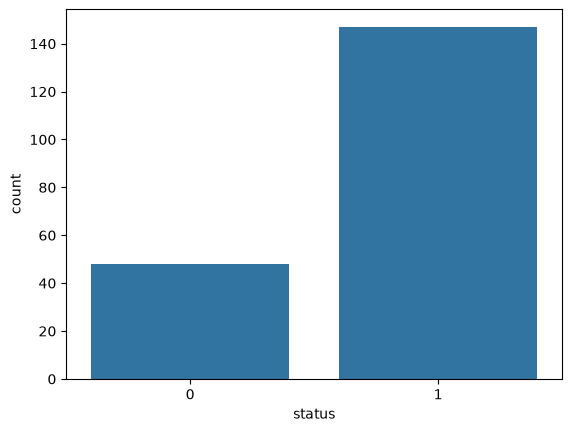

In [5]:
print(df["status"].value_counts())
sns.countplot(data=df,x="status")
plt.show()

In [6]:
df = df.drop("name", axis=1)

X = df.drop("status", axis=1)
y = df["status"]

print(X.shape, y.shape)
print("Total NaN:", X.isnull().sum().sum())

(195, 22) (195,)
Total NaN: 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_columns = X.columns.tolist()

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True,class_weight="balanced",random_state=42),
    "Naive Bayes": GaussianNB()
}

results=[]

for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    pred=model.predict(X_test_scaled)
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1 Score":f1_score(y_test,pred)
    })

results_df=pd.DataFrame(results).sort_values("F1 Score",ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.948718,0.965517,0.965517,0.965517
1,KNN,0.923077,0.933333,0.965517,0.949153
2,Decision Tree,0.794872,0.888889,0.827586,0.857143
3,SVM,0.794872,1.000000,0.724138,0.840000
4,Logistic Regression,0.769231,0.954545,0.724138,0.823529
5,Naive Bayes,0.666667,1.000000,0.551724,0.711111


Random Forest
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



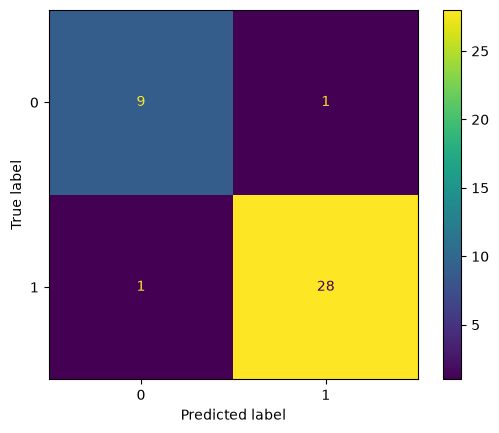

ROC AUC: 0.9793103448275862


In [9]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

pred = best_model.predict(X_test_scaled)

print(best_model_name)
print(classification_report(y_test,pred))

cm = confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

prob = best_model.predict_proba(X_test_scaled)[:,1]
print("ROC AUC:", roc_auc_score(y_test,prob))

In [10]:
MODEL_DIR = Path("../trained_models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_DIR/"parkinson_model.pkl")
joblib.dump(scaler, MODEL_DIR/"parkinson_scaler.pkl")
joblib.dump(feature_columns, MODEL_DIR/"parkinson_columns.pkl")

print("Model saved successfully.")

Model saved successfully.
